# 04_final_evaluation

In [2]:

from pathlib import Path
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for p in candidates:
        if (p / "data").exists() and (p / "results").exists():
            return p
    return cwd

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR = RESULTS_DIR / "figures"
PRED_DIR = RESULTS_DIR / "predictions"
MODEL_DIR = RESULTS_DIR / "models"

for d in [TABLE_DIR, FIG_DIR, PRED_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEXT_COL = "free_text"
LABEL_COL = "label_id"

LABEL_MAP = {
    0: "CLEAN",
    1: "OFFENSIVE",
    2: "HATE",
}
LABEL_ORDER = [0, 1, 2]
LABEL_NAMES = [LABEL_MAP[i] for i in LABEL_ORDER]

PROJECT_ROOT


WindowsPath('C:/Users/23110/OneDrive/Desktop/3rd_Year/HK2/Đợt 1/MAAI/From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation')

In [3]:

train_df = pd.read_csv(DATA_DIR / "train.csv")
dev_df = pd.read_csv(DATA_DIR / "dev.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, dev_df, test_df]:
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df["label_name"] = df[LABEL_COL].map(LABEL_MAP)

print("train:", train_df.shape)
print("dev  :", dev_df.shape)
print("test :", test_df.shape)

train_df.head()


train: (24048, 3)
dev  : (2672, 3)
test : (6680, 3)


,free_text,label_id,label_name
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0,CLEAN
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2,HATE
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,CLEAN
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2,HATE
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0,CLEAN


## best config from 03_linear_svm

In [4]:

BEST_CONFIG = {
    "preprocessing": "strong",
    "feature_name": "char_wb_3_5",
    "analyzer": "char_wb",
    "ngram_range": (3, 5),
    "min_df": 3,
    "max_df": 1.0,
    "C": 1.0,
    "class_weight": "balanced",
    "model_name": "lsvm_balanced_c1",
    "dev_accuracy": 0.8506736526946108,
    "dev_macro_f1": 0.6353865090498952,
    "dev_weighted_f1": 0.8516452412046014,
}

BEST_CONFIG


{'preprocessing': 'strong',
 'feature_name': 'char_wb_3_5',
 'analyzer': 'char_wb',
 'ngram_range': (3, 5),
 'min_df': 3,
 'max_df': 1.0,
 'C': 1.0,
 'class_weight': 'balanced',
 'model_name': 'lsvm_balanced_c1',
 'dev_accuracy': 0.8506736526946108,
 'dev_macro_f1': 0.6353865090498952,
 'dev_weighted_f1': 0.8516452412046014}

## preprocessing

In [5]:

def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

def remove_urls(text):
    return re.sub(r"(https?://\S+|www\.\S+)", " ", text)

def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{3,}", r"\1\1\1", text)

def normalize_repeated_punct(text):
    return re.sub(r"([!?.,:;])\1{2,}", r"\1\1", text)

def preprocess_light(text):
    text = str(text)
    text = normalize_whitespace(text)
    return text

def preprocess_medium(text):
    text = str(text).lower()
    text = remove_urls(text)
    text = normalize_whitespace(text)
    return text

def preprocess_strong(text):
    text = str(text).lower()
    text = remove_urls(text)
    text = normalize_repeated_chars(text)
    text = normalize_repeated_punct(text)
    text = normalize_whitespace(text)
    return text

PREPROCESSORS = {
    "light": preprocess_light,
    "medium": preprocess_medium,
    "strong": preprocess_strong,
}


## fit final model on train + dev

In [6]:

prep_fn = PREPROCESSORS[BEST_CONFIG["preprocessing"]]

train_dev_df = pd.concat([train_df, dev_df], ignore_index=True).copy()
train_dev_text = train_dev_df[TEXT_COL].map(prep_fn)
train_dev_y = train_dev_df[LABEL_COL].values

test_text = test_df[TEXT_COL].map(prep_fn)
test_y = test_df[LABEL_COL].values

vectorizer = TfidfVectorizer(
    analyzer=BEST_CONFIG["analyzer"],
    ngram_range=BEST_CONFIG["ngram_range"],
    min_df=BEST_CONFIG["min_df"],
    max_df=BEST_CONFIG["max_df"],
    lowercase=False,
    sublinear_tf=True,
)

X_train_dev = vectorizer.fit_transform(train_dev_text)
X_test = vectorizer.transform(test_text)

model = LinearSVC(
    C=BEST_CONFIG["C"],
    class_weight=BEST_CONFIG["class_weight"],
    random_state=RANDOM_SEED,
)

model.fit(X_train_dev, train_dev_y)
test_pred = model.predict(X_test)

print("train+dev matrix:", X_train_dev.shape)
print("test matrix     :", X_test.shape)


train+dev matrix: (26720, 31267)
test matrix     : (6680, 31267)


## test metrics

In [7]:

test_metrics = pd.DataFrame([
    {
        "split": "test",
        "accuracy": accuracy_score(test_y, test_pred),
        "macro_f1": f1_score(test_y, test_pred, average="macro"),
        "weighted_f1": f1_score(test_y, test_pred, average="weighted"),
    }
])

test_metrics.to_csv(TABLE_DIR / "final_test_metrics.csv", index=False)
test_metrics


,split,accuracy,macro_f1,weighted_f1
0,test,0.857485,0.631477,0.857331


## classification report

In [8]:

report_dict = classification_report(
    test_y,
    test_pred,
    labels=LABEL_ORDER,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(TABLE_DIR / "final_test_classification_report.csv")
report_df


,precision,recall,f1-score,support
CLEAN,0.931277,0.930606,0.930941,5548.000000
OFFENSIVE,0.425837,0.400901,0.412993,444.000000
HATE,0.538997,0.562500,0.550498,688.000000
accuracy,0.857485,0.857485,0.857485,0.857485
macro avg,0.632037,0.631336,0.631477,6680.000000
weighted avg,0.857279,0.857485,0.857331,6680.000000


## confusion matrix

In [9]:

cm = confusion_matrix(test_y, test_pred, labels=LABEL_ORDER)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{name}" for name in LABEL_NAMES],
    columns=[f"pred_{name}" for name in LABEL_NAMES],
)
cm_df.to_csv(TABLE_DIR / "final_test_confusion_matrix.csv")
cm_df


,pred_CLEAN,pred_OFFENSIVE,pred_HATE
true_CLEAN,5163,146,239
true_OFFENSIVE,174,178,92
true_HATE,207,94,387


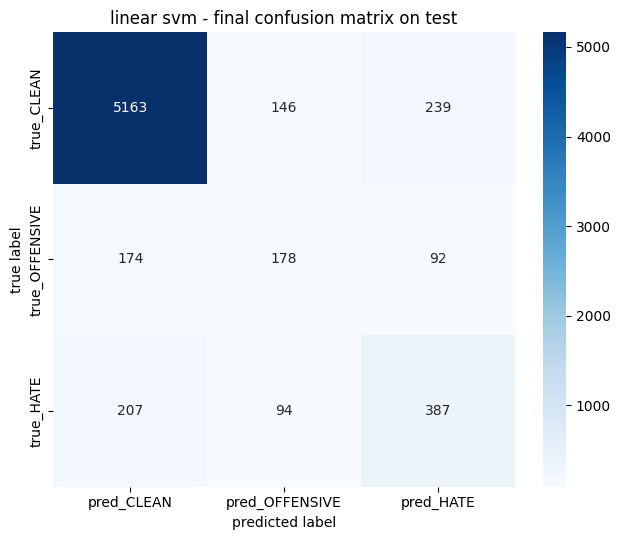

In [10]:

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("linear svm - final confusion matrix on test")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.tight_layout()
plt.savefig(FIG_DIR / "final_test_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## save final model and test predictions

In [11]:

joblib.dump(vectorizer, MODEL_DIR / "final_linear_svm_vectorizer.joblib")
joblib.dump(model, MODEL_DIR / "final_linear_svm_model.joblib")

test_pred_df = test_df.copy()
test_pred_df["processed_text"] = test_df[TEXT_COL].map(prep_fn)
test_pred_df["pred_label_id"] = test_pred
test_pred_df["pred_label_name"] = test_pred_df["pred_label_id"].map(LABEL_MAP)
test_pred_df["is_correct"] = (test_pred_df[LABEL_COL] == test_pred_df["pred_label_id"]).astype(int)

test_pred_df.to_csv(PRED_DIR / "final_test_predictions.csv", index=False)

print("saved:")
print("-", TABLE_DIR / "final_test_metrics.csv")
print("-", TABLE_DIR / "final_test_classification_report.csv")
print("-", TABLE_DIR / "final_test_confusion_matrix.csv")
print("-", FIG_DIR / "final_test_confusion_matrix.png")
print("-", MODEL_DIR / "final_linear_svm_vectorizer.joblib")
print("-", MODEL_DIR / "final_linear_svm_model.joblib")
print("-", PRED_DIR / "final_test_predictions.csv")


saved:
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results\tables\final_test_metrics.csv
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results\tables\final_test_classification_report.csv
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results\tables\final_test_confusion_matrix.csv
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results\figures\final_test_confusion_matrix.png
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\From Linear SVM to SVM Kernels - Kernel Methods for Vietnamese Content Moderation\results\models\final_linear_svm_vectorizer.joblib
- C:\Users\23110\OneDrive\Desktop\3rd_Year\HK2\Đợt 1\MAAI\

## quick error slices

In [12]:

errors_df = test_pred_df.loc[test_pred_df["is_correct"] == 0, [
    TEXT_COL, LABEL_COL, "label_name", "pred_label_id", "pred_label_name"
]].copy()

errors_df["pair"] = errors_df["label_name"] + " -> " + errors_df["pred_label_name"]

error_pair_counts = errors_df["pair"].value_counts().rename_axis("error_pair").reset_index(name="count")
error_pair_counts.to_csv(TABLE_DIR / "final_test_error_pair_counts.csv", index=False)

error_pair_counts


,error_pair,count
0,CLEAN -> HATE,239
1,HATE -> CLEAN,207
2,OFFENSIVE -> CLEAN,174
3,CLEAN -> OFFENSIVE,146
4,HATE -> OFFENSIVE,94
5,OFFENSIVE -> HATE,92


In [13]:

sample_errors = (
    errors_df.groupby("pair", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

sample_errors.to_csv(PRED_DIR / "final_test_sample_errors.csv", index=False)
sample_errors.head(20)


,free_text,label_id,label_name,pred_label_id,pred_label_name,pair
0,Đừng cố biện minh =)))) choi lon,0,CLEAN,1,OFFENSIVE,CLEAN -> OFFENSIVE
1,Haizz. Nthe này thì dân khổ quá,1,OFFENSIVE,0,CLEAN,OFFENSIVE -> CLEAN
2,coin card :3,1,OFFENSIVE,0,CLEAN,OFFENSIVE -> CLEAN
3,"Lý khùng thì có,kk",0,CLEAN,1,OFFENSIVE,CLEAN -> OFFENSIVE
4,Sét đánh chết tao đi,0,CLEAN,1,OFFENSIVE,CLEAN -> OFFENSIVE
5,"Đề nghị 17, 22,23,32 đến phà vài hơi vào mẹt t...",2,HATE,0,CLEAN,HATE -> CLEAN
6,"Nhà Xa trường học, nhà gần cầu tiêu câu nói đã...",0,CLEAN,2,HATE,CLEAN -> HATE
7,"K nói thì tự kiêu,nói thì lại tự ái chứ í thức...",1,OFFENSIVE,0,CLEAN,OFFENSIVE -> CLEAN
8,Co ba oi co giau lam vay co giup nhung nguoi k...,0,CLEAN,2,HATE,CLEAN -> HATE
9,Đập què giò đi a ba,0,CLEAN,1,OFFENSIVE,CLEAN -> OFFENSIVE
